In [42]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="llama-3.1-8b-instant")

In [43]:
#section state
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from typing import List

class Section(BaseModel):
    name: str=Field(description="gives the name of the section")
    description: str=Field(description="gives detailed description of the section")

class Sections(BaseModel):
    sections: List[Section]    

In [44]:
#binding model with structured output-example
structured_model = model.with_structured_output(Sections)
response=structured_model.invoke("a report with 2 sections on agentic ai")
response.sections

[Section(name='Introduction to Agentic AI', description='Agentic AI refers to a type of artificial intelligence that is designed to have its own goals, motivations, and decision-making processes, similar to those of a human agent.'),
 Section(name='Applications of Agentic AI', description='Agentic AI has the potential to be applied in various fields, such as healthcare, finance, and education, where it can help make decisions, solve complex problems, and learn from experiences.')]

In [45]:
#state schema of graph
import operator
from typing import Annotated

class State(BaseModel):
    topic:str=Field(description="topic to generate the report")
    number_of_sections:int=Field(default=None, description="number of sections generated")
    sections:List[Section]=Field(default=None, description="detailed sections of the report")
    completed_sections:Annotated[List, operator.add]=Field(default=None)
    final_report:str=Field(default=None, description="Final report with title and sections")

class WorkerState(BaseModel):
    section:Section=Field(description="details of the section")
    completed_sections:Annotated[List, operator.add]    

In [46]:
#nodes definition
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage


def orchestrator_node(state:State):
    response = structured_model.invoke(f"""Generate a plan for the report : {state.topic}""")
    print(f"{len(response.sections)} Report Sections: {response.sections}")
    return {"sections": response.sections, "number_of_sections": len(response.sections)}

def worker_node(worker_state:WorkerState):
    #generate section
    worked_section = model.invoke([
        SystemMessage(content="write a report section following the name and description. Include no preamble for each section."),
        HumanMessage(content=f"Here is the section name : {worker_state['section'].name} and description: {worker_state['section'].description}")
    ])
    return {"completed_sections": [worked_section.content]}

def assign_worker(state:State):
    "assigning worker to each section of the report plan"
    return [Send("worker_node", {"section":section}) for section in state.sections]

def synthesizer(state:State):
    final_report = "\n\n".join(state.completed_sections)
    return {"final_report": final_report}

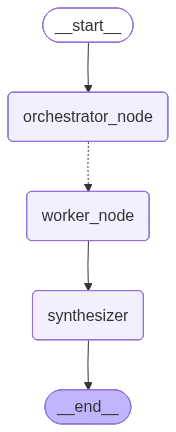

In [47]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

#adding nodes and edges

graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("synthesizer", synthesizer)

graph.add_edge(START, "orchestrator_node")
graph.add_conditional_edges("orchestrator_node", assign_worker, ["worker_node"])
graph.add_edge("worker_node", "synthesizer")
graph.add_edge("synthesizer", END)

graph_builder= graph.compile()
graph_builder

In [48]:
#invoking graph with topic


state = graph_builder.invoke({'topic': 'create a report on machine learning'})
print(f"Final report on {state['topic']}:\n\n{state['final_report']}")

6 Report Sections: [Section(name='Introduction', description='Overview of machine learning and its importance'), Section(name='History of Machine Learning', description='Evolution of machine learning from its early beginnings to the present day'), Section(name='Types of Machine Learning', description='Supervised, unsupervised, and reinforcement learning'), Section(name='Applications of Machine Learning', description='Real-world examples of machine learning in various industries'), Section(name='Challenges and Future Directions', description='Limitations and potential future developments in machine learning'), Section(name='Conclusion', description='Summary of key points and final thoughts')]
Final report on create a report on machine learning:

**Introduction and Description: Overview of Machine Learning and its Importance**

**Machine Learning Overview**

Machine learning is a subset of artificial intelligence (AI) that involves the development of algorithms and statistical models tha